## Problem Setup


**1-D Heat Transfer Equation**

$$\frac{\partial y}{\partial t} =\alpha \frac{\partial^2 y}{\partial x^2}$$

$$x\in[0,1]$$
$$t\in[0,1]$$

**Initial Condition:**
The initial condition is parameterized by the combination of K_modes sine waves
$$u(x,0) = \sum_{k=1}^{K_{\mathrm{modes}}} a_k \sin(k\pi x)$$

**Boundary Conditions:**

$$u(0,t)=0$$
$$u(1,t)=0$$

**Exact solution:**

$$u(x,t)
=
\sum_{k=1}^{K_{\mathrm{modes}}}
a_k
\exp\!\left(-\alpha (k\pi)^2 t\right)
\sin(k\pi x)$$

**Sensor Observation: with m sensor, n observation step, and observation period $\tau$**

$$y(x_i,t_j)=u(x_i,t_j)$$
$$x_i=\frac{i-1}{\text{m}},\;\; t_j=\frac{(j-1)\tau}{n}$$

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
np.random.seed(0)

Using device: cuda


**Set up for the Basic Parameters**

In [4]:
alpha = 0.1

# Determine the basis
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

# Determin the initial value represented by K basis function
K_modes = 10

# Number of spatial sensors
m_sensors = 10

# Number of observation time steps
n_obs_steps = 50

# Observation time window: we observe t in [0, t_obs_end]
t_obs_end = 0.1

# Sensor locations
x_sensors = torch.linspace(0, 1, m_sensors).view(1, -1).to(device)

# Observation times: t_0, ..., t_n_obs_steps-1
t_obs = torch.linspace(0, t_obs_end, n_obs_steps).view(-1, 1).to(device)

print("Number of sensors:", m_sensors)
print("Number of observation steps:", n_obs_steps)
print("Observation window: [0,", t_obs_end, "]")

Number of sensors: 10
Number of observation steps: 50
Observation window: [0, 0.1 ]


**The functions to generate random initial condition, closed form solution and sensor data**

In [ ]:
def sample_random_coefficients(batch_size):

    
    #u0(x) = sum_k a_k sin(k*pi*x)
    coeffs = torch.randn(batch_size, K_modes).to(device)

    # This makes higher-frequency modes smaller. Therefore, the generated initial condition is smoother.
    decay = torch.arange(1, K_modes + 1, device=device).float()
    coeffs = coeffs / decay

    return coeffs


def heat_solution(coeffs, x, t):
    #Determine the closed-form solution with coefficent of initial value
    result = 0.0

    for k in range(1, K_modes + 1):
        a_k = coeffs[:, k-1:k]
        result = result + a_k * torch.exp(-alpha * (k * np.pi)**2 * t) * torch.sin(k * np.pi * x)

    return result


def build_sensor_sequence(coeffs):
    
    #y(x_i, t_j), i = 1,...,m_sensors, j = 0,...,n_obs_steps

    sensor_values = []

    for j in range(n_obs_steps):
        tau = t_obs[j:j+1]  # shape (1,1)

        # u at all sensor locations at this observation time
        values_j = heat_solution(coeffs, x_sensors, tau)

        sensor_values.append(values_j)

    # Shape: (B, n_obs_steps, m_sensors)
    sensor_values = torch.stack(sensor_values, dim=1)

    # Flatten to shape: (B, n_obs_steps * m_sensors)
    sensor_sequence = sensor_values.reshape(coeffs.shape[0], -1)

    return sensor_sequence

**Define the Neural network structure**

In [ ]:
class SensorSequenceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=torch.tensor([128] * 8)):
        super(SensorSequenceNet, self).__init__()

        layers = []

        # Convert hidden_dim to a Python list of integers
        if isinstance(hidden_dim, torch.Tensor):
            hidden_dim = hidden_dim.tolist()

        # Make sure all elements are integers
        hidden_dim = [int(h) for h in hidden_dim]

        # First hidden layer
        layers.append(nn.Linear(input_dim, hidden_dim[0]))
        layers.append(nn.Tanh())

        # Remaining hidden layers
        for i in range(1, len(hidden_dim)):
            layers.append(nn.Linear(hidden_dim[i - 1], hidden_dim[i]))
            layers.append(nn.Tanh())

        # Output layer
        layers.append(nn.Linear(hidden_dim[-1], 1))

        self.net = nn.Sequential(*layers)

    def forward(self, sensor_sequence, x, t):
        input_data = torch.cat([sensor_sequence, x, t], dim=1)
        return self.net(input_data)

# sensor sequence + location + time
input_dim = n_obs_steps * m_sensors + 2

hidden_dim = torch.tensor([
    512,
    256,
    256,
    256,
    256,
    128
])

# setup the network structure
model = SensorSequenceNet(
    input_dim=input_dim,
    hidden_dim=hidden_dim
).to(device)

print(model)

# model = SensorSequenceNet(
#     input_dim=input_dim,
#     hidden_dim=512,
#     num_hidden_layers_1=6,

# ).to(device)

# print(model)

SensorSequenceNet(
  (net): Sequential(
    (0): Linear(in_features=502, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): Tanh()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): Tanh()
    (10): Linear(in_features=256, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)


**Generate training data with Closed-form solution**

In [ ]:
def generate_training_batch(N_f, N_data, N_bc):


    #N_f: PDE residual points
    #N_data: supervised solution points
    #N_bc: boundary condition points


    # -------------------------
    # PDE collocation points
    # -------------------------
    coeffs_f = sample_random_coefficients(N_f)
    sensor_f = build_sensor_sequence(coeffs_f)

    x_f = torch.rand(N_f, 1).to(device)

    # t is larger than observation window
    t_f = t_obs_end + (t_max - t_obs_end) * torch.rand(N_f, 1).to(device)

    # -------------------------
    # Supervised solution points
    # -------------------------
    coeffs_data = sample_random_coefficients(N_data)
    sensor_data = build_sensor_sequence(coeffs_data)

    x_data = torch.rand(N_data, 1).to(device)

    # prediction time is after the first n_obs_steps observation steps
    t_data = t_obs_end + (t_max - t_obs_end) * torch.rand(N_data, 1).to(device)

    u_data_true = heat_solution(coeffs_data, x_data, t_data)


    # Boundary condition points
    coeffs_bc = sample_random_coefficients(N_bc)
    sensor_bc = build_sensor_sequence(coeffs_bc)

    t_bc = t_obs_end + (t_max - t_obs_end) * torch.rand(N_bc, 1).to(device)

    x_bc_left = torch.zeros(N_bc, 1).to(device)
    x_bc_right = torch.ones(N_bc, 1).to(device)

    u_bc_left_true = torch.zeros(N_bc, 1).to(device)
    u_bc_right_true = torch.zeros(N_bc, 1).to(device)

    return {
        "sensor_f": sensor_f, #function data
        "x_f": x_f,
        "t_f": t_f,

        "sensor_data": sensor_data, 
        "x_data": x_data,   # approximation data
        "t_data": t_data,
        "u_data_true": u_data_true,

        "sensor_bc": sensor_bc, #boundary data
        "x_bc_left": x_bc_left,
        "x_bc_right": x_bc_right,
        "t_bc": t_bc,
        "u_bc_left_true": u_bc_left_true,
        "u_bc_right_true": u_bc_right_true,
    }

**Compute the total loss with Physical-informed PDE Loss, Data Loss, and Boundary Loss**

In [ ]:
# function for computing the PDE loss
def pde_residual(model, sensor_sequence, x, t):
 
    #PDE residual: f = u_t - alpha u_xx

    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(sensor_sequence, x, t)

    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        retain_graph=True,
        create_graph=True
    )[0]

    f = u_t - alpha * u_xx

    return f


def compute_loss(model, batch):

    #Total loss: loss = data loss + PDE residual loss + boundary condition loss


    # PDE residual loss
    f = pde_residual(
        model,
        batch["sensor_f"],
        batch["x_f"],
        batch["t_f"]
    )

    loss_pde = torch.mean(f**2)

    # Supervised solution loss
    u_data_pred = model(
        batch["sensor_data"],
        batch["x_data"],
        batch["t_data"]
    )

    loss_data = torch.mean((u_data_pred - batch["u_data_true"])**2)

    # Boundary condition loss
    u_left_pred = model(
        batch["sensor_bc"],
        batch["x_bc_left"],
        batch["t_bc"]
    )

    u_right_pred = model(
        batch["sensor_bc"],
        batch["x_bc_right"],
        batch["t_bc"]
    )

    loss_bc_left = torch.mean((u_left_pred - batch["u_bc_left_true"])**2)
    loss_bc_right = torch.mean((u_right_pred - batch["u_bc_right_true"])**2)

    loss_bc = loss_bc_left + loss_bc_right

    # Weights for the loss for different parts, with the boundary loss higher
    lambda_data = 1.0
    lambda_pde = 1.0
    lambda_bc = 10.0

    loss = (
        lambda_data * loss_data
        + lambda_pde * loss_pde
        + lambda_bc * loss_bc
    )

    return loss, loss_data, loss_pde, loss_bc

**Determin the optimizer setup**

In [9]:

# optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=500,   # reduce learning rate every 500 optimizer steps
    gamma=0.97        # multiply learning rate by 0.5
)

num_epochs = 60000
print_every = 500

# number of sample for computing PDE loss
N_f = 2000

# number of sample for computing Prediction loss
N_data = 5000

# number of sample for computing Boundary loss
N_bc = 1000

loss_history = []

for epoch in range(1, num_epochs + 1):

    batch = generate_training_batch(N_f, N_data, N_bc)

    optimizer.zero_grad()

    loss, loss_data, loss_pde, loss_bc = compute_loss(model, batch)

    loss.backward()

    optimizer.step()

    scheduler.step()

    loss_history.append(loss.item())

    if epoch % print_every == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total Loss: {loss.item():.4e} | "
            f"Data: {loss_data.item():.4e} | "
            f"PDE: {loss_pde.item():.4e} | "
            f"BC: {loss_bc.item():.4e}"
        )

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch   500 | Total Loss: 1.8947e-01 | Data: 1.8396e-01 | PDE: 9.9039e-09 | BC: 5.5051e-04
Epoch  1000 | Total Loss: 2.0411e-01 | Data: 1.9679e-01 | PDE: 3.0710e-09 | BC: 7.3202e-04
Epoch  1500 | Total Loss: 2.0043e-01 | Data: 1.9466e-01 | PDE: 3.4482e-08 | BC: 5.7709e-04
Epoch  2000 | Total Loss: 2.0007e-01 | Data: 1.9322e-01 | PDE: 6.1437e-09 | BC: 6.8446e-04
Epoch  2500 | Total Loss: 1.8843e-01 | Data: 1.8241e-01 | PDE: 1.7427e-07 | BC: 6.0188e-04
Epoch  3000 | Total Loss: 1.8604e-01 | Data: 1.7868e-01 | PDE: 9.0410e-07 | BC: 7.3593e-04
Epoch  3500 | Total Loss: 1.7994e-01 | Data: 1.3299e-01 | PDE: 6.0394e-03 | BC: 4.0904e-03
Epoch  4000 | Total Loss: 1.1320e-01 | Data: 9.6329e-02 | PDE: 6.0957e-03 | BC: 1.0771e-03
Epoch  4500 | Total Loss: 4.7166e-02 | Data: 3.0916e-02 | PDE: 1.2088e-02 | BC: 4.1623e-04
Epoch  5000 | Total Loss: 2.7986e-02 | Data: 1.7651e-02 | PDE: 5.9098e-03 | BC: 4.4259e-04
Epoch  5500 | Total Loss: 2.3386e-02 | Data: 1.5864e-02 | PDE: 4.9337e-03 | BC: 2.5881e-04

**Plot the loss history**

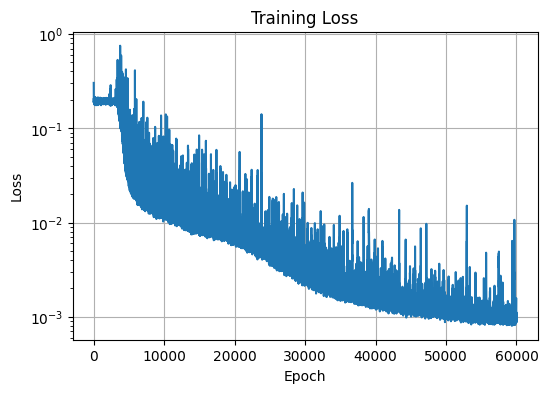

In [10]:
plt.figure(figsize=(6, 4))
plt.semilogy(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

**Generate new Trajectory for Test**

In [ ]:
# Generate one new test PDE trajectory
coeffs_test = sample_random_coefficients(1)

# Build its first 10-step sensor observation sequence
sensor_test = build_sensor_sequence(coeffs_test)

# Evaluation grid
Nx = 500
Nt = 500

x = torch.linspace(0, 1, Nx).view(-1, 1).to(device)

# Only test future times after observation window
t = torch.linspace(t_obs_end, 1, Nt).view(-1, 1).to(device)

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")

x_test = X.reshape(-1, 1)
t_test = T.reshape(-1, 1)

# Repeat sensor sequence for all query points
sensor_test_repeated = sensor_test.repeat(x_test.shape[0], 1)

with torch.no_grad():
    u_pred = model(
        sensor_test_repeated,
        x_test,
        t_test
    ).cpu().numpy()

u_pred = u_pred.reshape(Nx, Nt)

# Exact solution
coeffs_test_repeated = coeffs_test.repeat(x_test.shape[0], 1)

u_true = heat_solution(
    coeffs_test_repeated,
    x_test,
    t_test
).detach().cpu().numpy()

u_true = u_true.reshape(Nx, Nt)

error = np.abs(u_pred - u_true)

print("Mean absolute error:", np.mean(error))
print("Max absolute error:", np.max(error))

Mean absolute error: 0.0066646887
Max absolute error: 0.081038475


**Visulization of the sensor data**

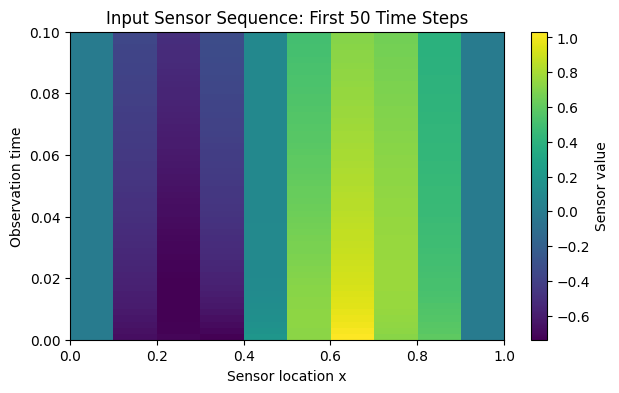

In [ ]:
sensor_matrix = sensor_test.reshape(n_obs_steps, m_sensors).detach().cpu().numpy()

plt.figure(figsize=(7, 4))
plt.imshow(
    sensor_matrix,
    aspect="auto",
    origin="lower",
    extent=[0, 1, 0, t_obs_end]
)
plt.colorbar(label="Sensor value")
plt.xlabel("Sensor location x")
plt.ylabel("Observation time")
plt.title("Input Sensor Sequence: First 50 Time Steps")
plt.show()

**Verification of the Learning Performance**

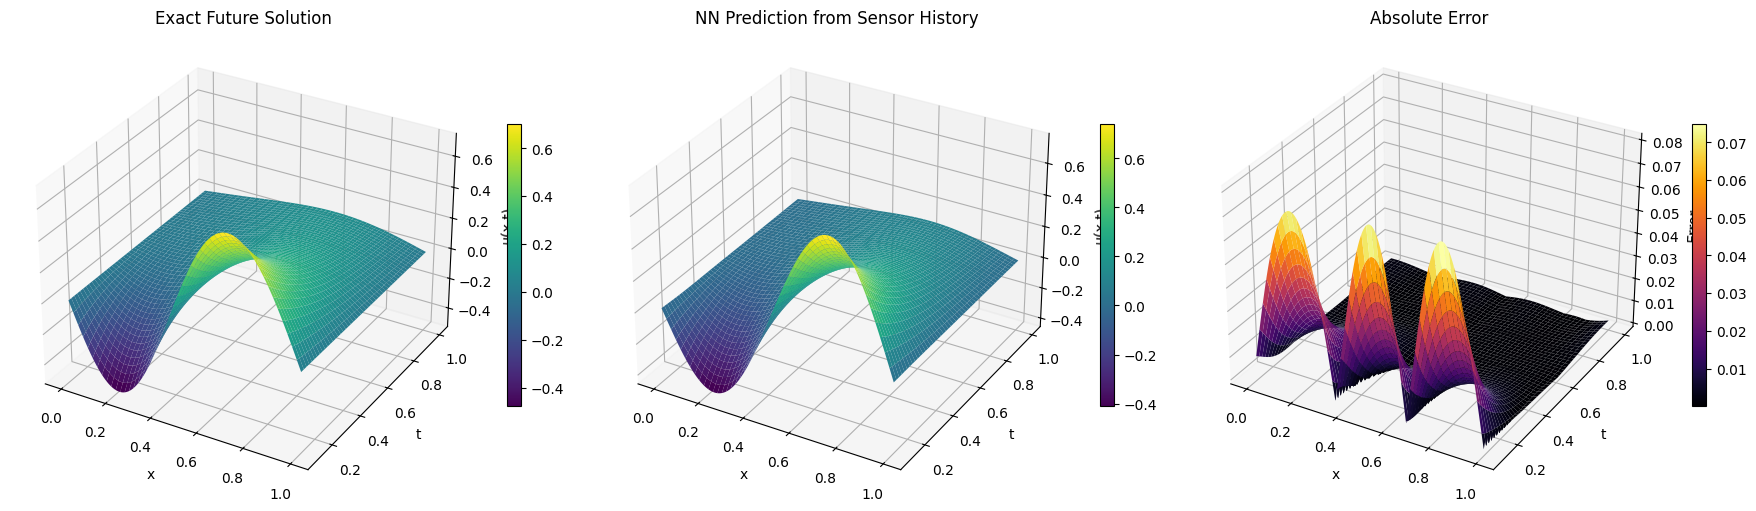

In [13]:
from mpl_toolkits.mplot3d import Axes3D

X_np = X.detach().cpu().numpy()
T_np = T.detach().cpu().numpy()

fig = plt.figure(figsize=(18, 5))

# Exact solution
ax1 = fig.add_subplot(131, projection="3d")
surf1 = ax1.plot_surface(X_np, T_np, u_true, cmap="viridis")
ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_zlabel("u(x,t)")
ax1.set_title("Exact Future Solution")
fig.colorbar(surf1, ax=ax1, shrink=0.6)

# Neural network prediction
ax2 = fig.add_subplot(132, projection="3d")
surf2 = ax2.plot_surface(X_np, T_np, u_pred, cmap="viridis")
ax2.set_xlabel("x")
ax2.set_ylabel("t")
ax2.set_zlabel("u(x,t)")
ax2.set_title("NN Prediction from Sensor History")
fig.colorbar(surf2, ax=ax2, shrink=0.6)

# Absolute error
ax3 = fig.add_subplot(133, projection="3d")
surf3 = ax3.plot_surface(X_np, T_np, error, cmap="inferno")
ax3.set_xlabel("x")
ax3.set_ylabel("t")
ax3.set_zlabel("Error")
ax3.set_title("Absolute Error")
fig.colorbar(surf3, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.show()

In [16]:
import os
import torch

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": loss_history,
    "num_epochs": num_epochs,

    # important hyperparameters
    "K_modes": K_modes,
    "m_sensors": m_sensors,
    "n_obs_steps": n_obs_steps,
}, "results/checkpoint.pth")

In [17]:
import pandas as pd

pd.DataFrame({"loss": loss_history}).to_csv(
    "results/loss_history.csv",
    index=False
)

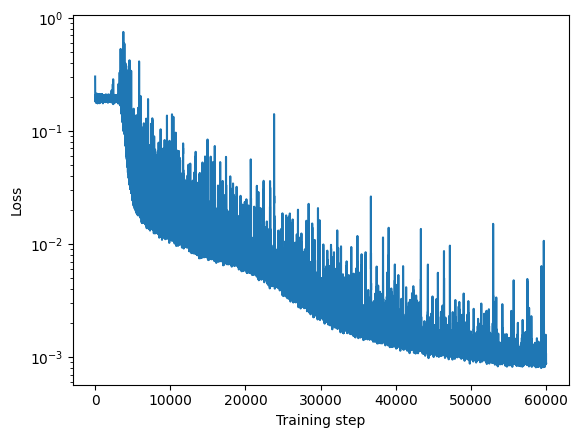

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.yscale("log")
plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")